# Conditional Moments in the ISLP Wage Dataset

This notebook explores how wages change with age using the Mid-Atlantic Wage Survey. It demonstrates conditional mean and variance analysis through `Plotter`, and the `partial_out` feature for controlling confounders. The partialling-out procedure uses the Chernozhukov et al. (2018) double ML approach: residualizing Y and X with Z through k-fold cross-validation.

## Setup

```bash
pip install kernelmoments ISLP
```

In [6]:
import matplotlib.pyplot as plt
from ISLP import load_data
from kernelmoments import Plotter

## Load data

The ISLP Wage dataset has 3,000 observations of Mid-Atlantic male workers.

Key variables:
- `wage` — weekly wage in thousands of dollars
- `age` — 18 to 80
- `education` — 5 ordinal levels (< HS Grad through Advanced Degree)
- `logwage` — log-transformed wage
- `jobclass` — Industrial or Information
- `year` — 2003 to 2009

In [7]:
df = load_data('Wage')
df['education_num'] = df['education'].cat.codes + 1
p = Plotter(df=df)
df.head()

,year,age,maritl,race,education,region,jobclass,health,health_ins,logwage,wage,education_num
0,2006,18,1. Never Married,1. White,1. < HS Grad,2. Middle Atlantic,1. Industrial,1. <=Good,2. No,4.318063,75.043154,1
1,2004,24,1. Never Married,1. White,4. College Grad,2. Middle Atlantic,2. Information,2. >=Very Good,2. No,4.255273,70.476020,4
2,2003,45,2. Married,1. White,3. Some College,2. Middle Atlantic,1. Industrial,1. <=Good,1. Yes,4.875061,130.982177,3
3,2003,43,2. Married,3. Asian,4. College Grad,2. Middle Atlantic,2. Information,2. >=Very Good,1. Yes,5.041393,154.685293,4
4,2005,50,4. Divorced,1. White,2. HS Grad,2. Middle Atlantic,2. Information,1. <=Good,1. Yes,4.318063,75.043154,2


## Conditional mean: E[wage | age]

We plot both the raw relationship between wage and age and the relationship after partialling out education via cross-fitted residualization. The left panel shows the raw relationship and the right panel shows the partialled out relationship controlling for education. The y- and x-axes are different in the right panel because it shows the residualized wage and residualized age, i.e. what is left of wage and age after partialling out education. 

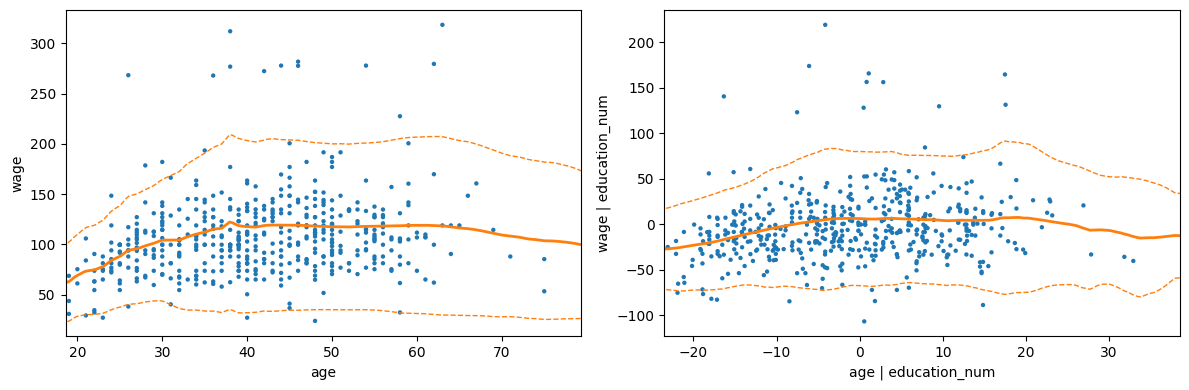

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
p.plot(x='age', y='wage', moment='mean', bands=True, ax=ax1)
p.plot(x='age', y='wage', moment='mean', partial_out='education_num', bands=True, ax=ax2)
fig.tight_layout()

## Conditional variance: Var[wage | age]
We repeat the same analysis as above for conditional variance. Clearly, some but not all of the wage spread at a given age is driven by educational differences, as the partialled-out variance in the right panel is lower. The x-axes are different as the right panel has the partialled-out age. 

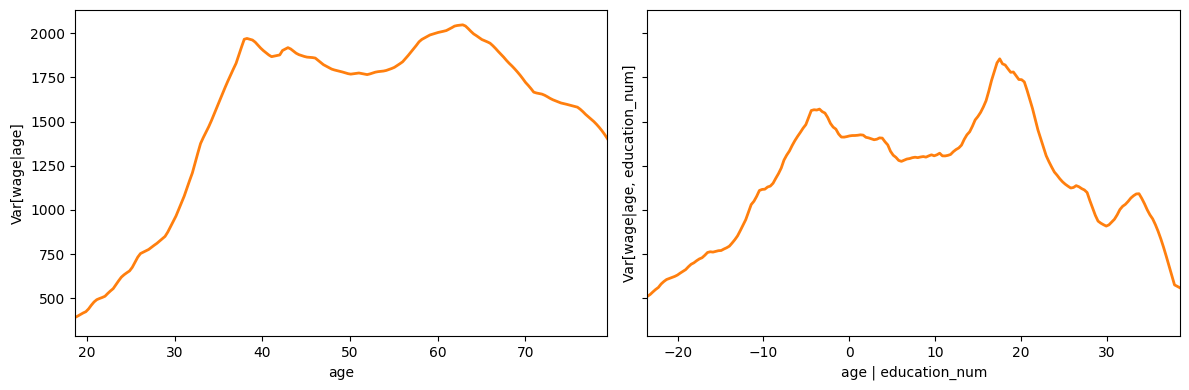

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
p.plot(x='age', y='wage', moment='variance', ax=ax1)
p.plot(x='age', y='wage', moment='variance', partial_out='education_num', ax=ax2)
fig.tight_layout()

## References

Chernozhukov, V., Chetverikov, D., Demirer, M., Duflo, E., Hansen, C., Newey, W., & Robins, J. (2018). Double/debiased machine learning for treatment and structural parameters.